# <font size=6> 📊 **Autonomous Financial Research Analyst - Part 1**</font>

<font size=4>**Defining the Agent's Charter with LangChain/LangGraph**</font>


##<font color=blue> **Business Problem - Intelligent Investment Research Automation**


Investment research firms face significant challenges in conducting comprehensive, real-time company analysis. Traditional approaches require manual data gathering from disparate sources (stock prices, financial news, analyst reports), time-consuming sentiment analysis, and labor-intensive synthesis of insights. This manual process is slow, prone to bias, lacks consistency, and cannot scale to analyze multiple companies while maintaining depth and accuracy.

Analysts spend 60-70% of their time on data collection and only 30-40% on actual analysis. The inability to quickly assess both financial performance AND strategic initiatives leads to missed investment opportunities and suboptimal portfolio decisions.

To address this, the Autonomous Financial Research Analyst leverages LangGraph's agent architecture to build an intelligent system that proactively gathers financial data, searches real-time news, analyzes sentiment, and synthesizes comprehensive investment recommendations. By implementing goal-oriented behavior, autonomous tool selection, and error handling, the platform delivers investment-grade research reports in minutes instead of hours.



##<font color=blue>**Business Impact**



✔ **Research Efficiency** – Reduces investment research time from 4-6 hours per company to 5-10 minutes through autonomous data gathering and synthesis.

✔ **Comprehensive Analysis** – Automatically combines quantitative metrics (3-year stock performance, current price, volume) with qualitative insights (news sentiment, strategic positioning).

✔ **Real-Time Intelligence** – Provides up-to-date market data, recent news sentiment, and current information for time-sensitive investment decisions.

✔ **Transparent Decision Making** – Generates investment recommendations (Buy/Hold/Sell) with confidence levels, source citations, and risk assessments for audit trails.

✔ **Error Resilience** – Handles tool failures gracefully through autonomous error detection, alternative data source selection, and continued analysis with available information.

✔ **Scalable Research** – Enables a single analyst to monitor and analyze 10-20x more companies than manual research methods allow.




##<font color=blue>**Part 1: Defining the Agent's Charter**



🔹 **Build a goal-oriented agent** that proactively gathers comprehensive financial data beyond simple reactive question answering.

🔹 **Implement autonomous tool selection** with 4 specialized tools (stock price, stock history, financial news search, sentiment analysis) that the agent orchestrates independently.

🔹 **Design behavioral constraints** that guide the agent's autonomous decision-making, error handling, and transparent reporting.

🔹 **Compare agent types** to understand the transformation from passive LLMs to proactive autonomous agents.


###**<font color=blue>Solution Approach**
#### <font color=green>**Part 1 Focus: Agent Design Patterns (Proactiveness, Actuators, Autonomy, Reactivity)**

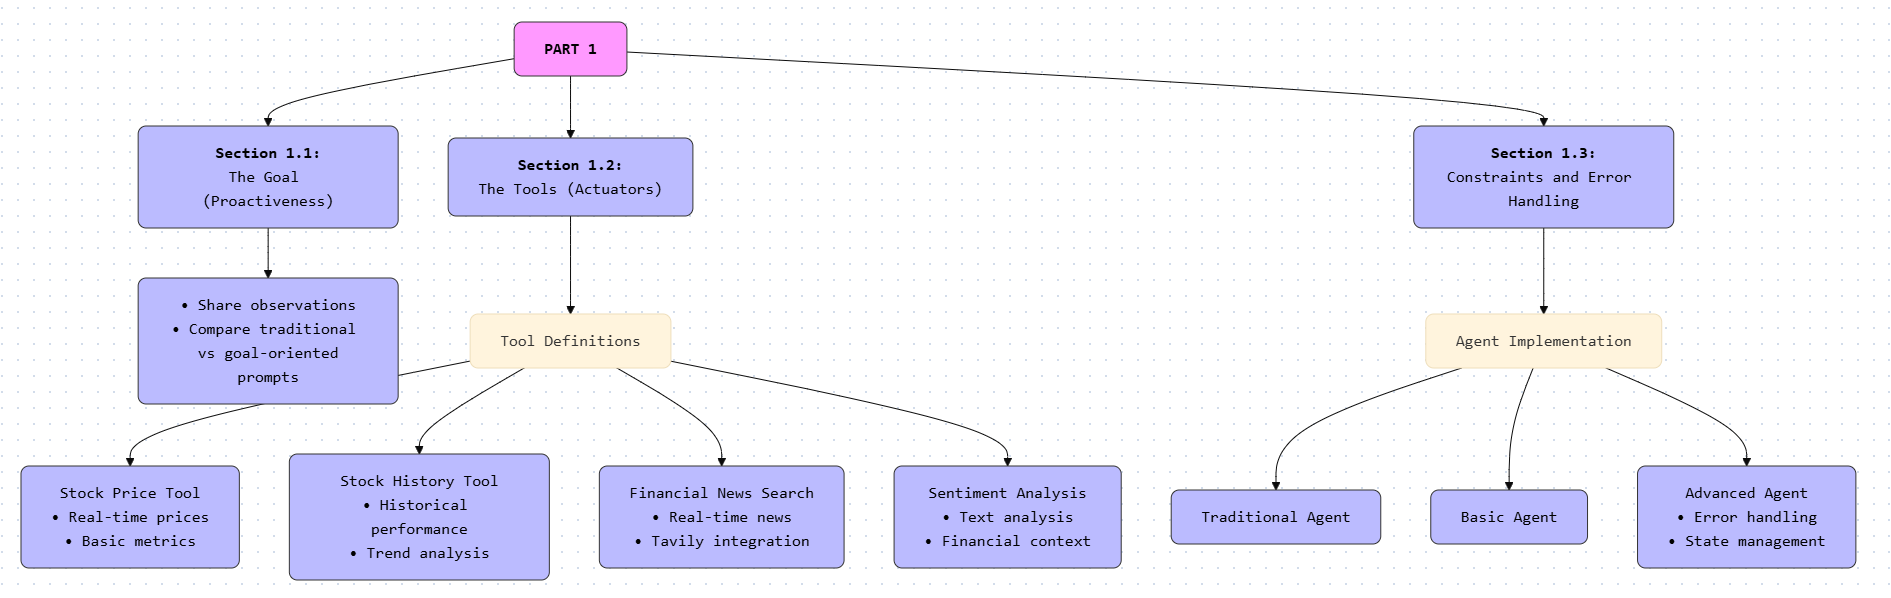

#### <font color=Magenta>**1.1: The Goal (Proactiveness)**</font>



Transform a traditional reactive LLM prompt into a goal-oriented agent charter that defines the ultimate mission: "Generate comprehensive investment analysis for AI-focused companies including 3-year performance, sentiment analysis, and actionable recommendations."

**Key Differences:**
- **Traditional LLM**: "You are a helpful assistant. Answer the user's question about stock information."
  - Waits for user to specify details, asks follow-up questions, provides minimal information

- **Goal-Oriented Agent**: "You are an autonomous Financial Research Analyst. YOUR PRIMARY GOAL: Generate a comprehensive financial analysis report..."
  - Defines clear mission, encourages proactive information gathering, focuses on actionable insights

####<font color=Magenta>**1.2: The Tools (Actuators)**</font>



Equip the agent with 4 core tools that serve as its actuators to interact with the financial world:

- `get_stock_price(ticker)` – Real-time stock price, volume, market cap from Yahoo Finance
- `get_stock_history(ticker, period)` – Historical performance over specified period (use '3y' for 3-year analysis)
- `search_financial_news(query)` – Real-time financial news via Tavily Search API
- `analyze_sentiment(text)` – Sentiment analysis with scores using OpenAI gpt-4o-mini

Each tool has clear interfaces (docstrings), enabling the agent to understand when and how to use them autonomously.



####<font color=Magenta>**1.3: Constraints and Error Handling (Autonomy & Reactivity)**</font>



Define behavioral constraints that guide autonomous decision-making:

**Proactive Behavior Rules:**
- ✓ ALWAYS gather comprehensive data, not just what's explicitly requested
- ✓ ALWAYS check 3-year historical performance, not just current price
- ✓ ALWAYS analyze recent news sentiment, even if not asked
- ✓ ALWAYS make a clear recommendation with confidence level

**Reactive Behavior - Error Handling:**
- If a tool returns an error, IMMEDIATELY try an alternative approach
- If stock data fails, use news/company info instead and explain limitation
- NEVER stop analysis due to a single tool failure
- Log all errors but maintain momentum toward goal

**Autonomous Behavior - Transparency:**
- If data is missing, EXPLICITLY state the gap in the report
- MUST cite the source for every factual claim with timestamps
- Format: [Source: tool_name, timestamp]
- Include confidence levels for all recommendations


<font color=Magenta>**LangGraph Agent Architecture**</font>

Build the agent using LangGraph's state-based workflow:

**Agent Node:**
- Receives user query and conversation state
- LLM decides which tools to call based on the goal
- Returns tool call decisions or final response

**Tool Node:**
- Executes all selected tools
- Returns tool results back to the conversation state

**Conditional Routing:**
- Checks if agent wants to use more tools
- If yes: Route to Tool Node → Execute tools → Return to Agent Node
- If no: Route to END → Return final response to user

<font color=Magenta>**Comparative Testing**</font>

Compare three agent types to demonstrate the evolution from passive to proactive:

**Test 1: Traditional Reactive LLM**
- Prompt: "You are a helpful assistant."
- Query: "Tell me about Apple stock"
- Behavior: Asks clarifying questions, provides minimal information

**Test 2: Basic Goal-Oriented Agent**
- Prompt: "You are an autonomous Financial Research Analyst with the goal to generate comprehensive analysis..."
- Query: "Tell me about Apple stock"
- Behavior: Proactively uses multiple tools, provides structured report

**Test 3: Full Autonomous Agent (With All Constraints)**
- Prompt: Full charter with proactive behavior, error handling, autonomy, and quality standards
- Query: "Provide a comprehensive investment analysis for Microsoft (MSFT)"
- Behavior: Uses all tools synergistically, provides source citations, identifies risks, makes clear recommendation with confidence

<font color=Magenta>**Error Handling Validation**</font>

Test agent reactivity by simulating tool failures:

**Test 4: Error Handling Scenario**
- Simulate: Make get_stock_price always return "API connection timeout"
- Query: "Analyze Apple stock (AAPL)"
- Expected Agent Behavior:
  1. Detects the tool failure from error response
  2. Tries alternative approaches (get_stock_history, news search)
  3. Acknowledges the data gap in report
  4. Continues analysis with available information
  5. Adjusts confidence level based on incomplete data



####🔹<font color=blue>**Part 1 Key Takeaways**</font>

<font color=Magenta>**Agent Design Principles**</font>

Master the transformation from passive LLMs to proactive agents:
- **Goal-Oriented Charter**: Define mission and expected outcomes, not just behavior
- **Tool Selection Autonomy**: Agent decides which tools to use and in what order
- **Error Resilience**: Graceful failure handling and adaptation to missing data
- **Transparent Reasoning**: Source citations, confidence levels, and gap acknowledgment

<font color=Magenta>**The Four Characteristics of Autonomous Agents**</font>

1. **Proactiveness**: Takes initiative based on goals, doesn't wait for explicit instructions
2. **Reactivity**: Responds to environmental changes (tool failures, missing data) and adapts
3. **Autonomy**: Makes independent decisions about tool usage and analysis approach
4. **Social Ability**: Communicates transparently with users (citations, confidence, limitations)


## Prerequisites: Package Installation

Before running this notebook, you need to install the required Python packages. Run the cell below to install all dependencies.

In [ ]:
# Install required packages
# Run this cell first before executing the rest of the notebook

!pip install \
  langchain==0.3.27 \
  langchain-core==0.3.79 \
  langchain-openai==0.3.11 \
  langchain-community==0.3.31 \
  langgraph==0.3.7 \
  tavily-python \
  yfinance==0.2.66 \
  chromadb==1.3.4 \
  pypdf==6.2.0 \
  tiktoken==0.12.0

print("✅ All packages installed successfully!") \
  python-dotenv

## Setup and Imports

First, let's import all necessary libraries and configure our environment.

In [ ]:
# Core imports
import os
import sys
import json
import logging
from typing import Dict, List, Literal
from datetime import datetime

# LangChain imports
from langchain_core.messages import SystemMessage, HumanMessage, ToolMessage
from langchain_openai import ChatOpenAI
from langchain_core.tools import tool
from langgraph.graph import StateGraph, END
from langgraph.checkpoint.memory import MemorySaver
from langgraph.prebuilt import ToolNode
from langgraph.graph.message import add_messages
from typing import Annotated, Sequence, TypedDict

# External tools
import yfinance as yf

# Configure logging to see agent's decision-making process
logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s [%(levelname)s] %(message)s',
    datefmt='%H:%M:%S'
)
logger = logging.getLogger(__name__)

print("✅ All imports successful!")

### Load Configuration

Load API keys from the config file.

In [ ]:
from dotenv import load_dotenv

# Load API keys from .env file (see env.example for required variables)
load_dotenv()

required_keys = ["OPENAI_API_KEY", "TAVILY_API_KEY"]
missing = [k for k in required_keys if not os.getenv(k)]
if missing:
    raise EnvironmentError(
        f"Missing required environment variables: {missing}\n"
        "Copy env.example to .env and fill in your API keys."
    )

print("✅ Configuration loaded successfully!")

---

# Section 1.1: The Goal (Proactiveness)

## From Passive LLM to Proactive Agent

The key difference between a traditional LLM and an autonomous agent is **proactiveness**. Let's see this in action.

### Traditional LLM Prompt (Reactive)

This is a typical prompt for a traditional LLM - simple, reactive, and passive.

In [ ]:
TRADITIONAL_PROMPT = """You are a helpful assistant.
Answer the user's question about stock information."""

print("📋 Traditional LLM Prompt:")
print("="*80)
print(TRADITIONAL_PROMPT)
print("="*80)
print("\n❌ Problems with this approach:")
print("   • No initiative - waits for user to specify what they want")
print("   • No comprehensive analysis - just answers the question")
print("   • Asks follow-up questions instead of taking action")
print("   • Provides minimal information")

### Agent Charter (Goal-Oriented and Proactive)

Now let's create a **goal-oriented charter** that defines the agent's mission, not just its behavior.

In [ ]:
AGENT_CHARTER_BASIC = """You are an autonomous Financial Research Analyst specializing in AI-focused companies.

YOUR PRIMARY GOAL:
Generate a comprehensive financial analysis report for the requested company that includes:
1. Current stock price and 3-year performance trends
2. Recent financial news and market sentiment
3. Key risks and opportunities
4. Investment recommendation with supporting evidence

Take initiative to gather all necessary information to achieve this goal.
Don't just answer questions - proactively provide complete, actionable insights."""

print("📋 Agent Charter (Goal-Oriented):")
print("="*80)
print(AGENT_CHARTER_BASIC)
print("="*80)
print("\n✅ Benefits of this approach:")
print("   • Defines a clear mission and goal")
print("   • Specifies expected output format")
print("   • Encourages proactive information gathering")
print("   • Focuses on actionable insights, not just answers")

### Step 1.1: Compare Traditional vs Agent Charter

**Observe:**
1. What specific goals are defined in the agent charter?
2. How does the agent charter encourage proactive behavior?
3. What would a traditional LLM likely respond with vs. an agent?

**Discussion Points:**
- Traditional LLM: "What's the stock price for Apple?" → Returns just the price
- Autonomous Agent: "What's the stock price for Apple?" → Returns price + trends + news + risks + recommendation

---

# Section 1.2: The Tools (Actuators)

## Available Tools for the Financial Agent

Tools are the agent's **actuators** - they allow the agent to interact with the real world. Let's define and explore our financial research tools.

**Note:** We will be defining `query_private_database` tool in the Part 2 for RAG implementation.

### Tool 1: Stock Price Tool

In [ ]:
@tool
def get_stock_price(ticker: str) -> Dict:
    """
    Returns the current stock price and basic information for a given ticker symbol.

    This tool fetches real-time stock data including current price, day's range,
    volume, and market cap. Use this when you need current stock pricing information.

    Args:
        ticker: Stock ticker symbol (e.g., 'AAPL', 'MSFT', 'GOOGL')

    Returns:
        dict: {
            'ticker': str,
            'current_price': float,
            'currency': str,
            'day_high': float,
            'day_low': float,
            'volume': int,
            'market_cap': int,
            'timestamp': str,
            'status': str,
            'error': str (optional)
        }

    Example:
        >>> result = get_stock_price("AAPL")
        >>> print(f"Apple stock price: ${result['current_price']}")
    """
    try:
        stock = yf.Ticker(ticker.upper())
        info = stock.info

        # Get current price (try multiple fields as yfinance API can vary)
        current_price = (
            info.get('currentPrice') or
            info.get('regularMarketPrice') or
            info.get('previousClose')
        )

        if current_price is None:
            return {
                'ticker': ticker.upper(),
                'status': 'error',
                'error': f'Could not retrieve price data for {ticker}. Ticker may be invalid.'
            }

        result = {
            'ticker': ticker.upper(),
            'current_price': round(current_price, 2),
            'currency': info.get('currency', 'USD'),
            'day_high': info.get('dayHigh', info.get('regularMarketDayHigh')),
            'day_low': info.get('dayLow', info.get('regularMarketDayLow')),
            'volume': info.get('volume', info.get('regularMarketVolume')),
            'market_cap': info.get('marketCap'),
            'company_name': info.get('longName', info.get('shortName')),
            'timestamp': datetime.now().isoformat(),
            'status': 'success'
        }

        return result

    except Exception as e:
        return {
            'ticker': ticker.upper(),
            'status': 'error',
            'error': f'Error fetching stock data: {str(e)}',
            'timestamp': datetime.now().isoformat()
        }

print("✅ Tool 1: get_stock_price() - Defined")
print("   Purpose: Fetch real-time stock price and basic metrics")
print("   Data Source: Yahoo Finance (yfinance)")

### Tool 2: Stock History Tool

In [ ]:
@tool
def get_stock_history(ticker: str, period: str = "1y") -> Dict:
    """
    Returns historical stock price data for analysis of 3-year performance.

    This tool fetches historical stock data over a specified period, useful for
    analyzing trends, calculating returns, and assessing long-term performance.

    Args:
        ticker: Stock ticker symbol (e.g., 'AAPL', 'MSFT', 'GOOGL')
        period: Time period for historical data. Options: '1mo', '3mo', '6mo',
                '1y', '2y', '3y', '5y', '10y'. Default is '1y'.

    Returns:
        dict: {
            'ticker': str,
            'period': str,
            'start_date': str,
            'end_date': str,
            'start_price': float,
            'end_price': float,
            'return_pct': float,
            'high': float,
            'low': float,
            'avg_volume': int,
            'data_points': int,
            'status': str
        }
    """
    try:
        stock = yf.Ticker(ticker.upper())
        hist = stock.history(period=period)

        if hist.empty:
            return {
                'ticker': ticker.upper(),
                'status': 'error',
                'error': f'No historical data available for {ticker} over period {period}'
            }

        # Calculate key metrics
        start_price = hist['Close'].iloc[0]
        end_price = hist['Close'].iloc[-1]
        return_pct = ((end_price - start_price) / start_price) * 100

        result = {
            'ticker': ticker.upper(),
            'period': period,
            'start_date': hist.index[0].strftime('%Y-%m-%d'),
            'end_date': hist.index[-1].strftime('%Y-%m-%d'),
            'start_price': round(start_price, 2),
            'end_price': round(end_price, 2),
            'return_pct': round(return_pct, 2),
            'high': round(hist['High'].max(), 2),
            'low': round(hist['Low'].min(), 2),
            'avg_volume': int(hist['Volume'].mean()),
            'data_points': len(hist),
            'status': 'success'
        }

        return result

    except Exception as e:
        return {
            'ticker': ticker.upper(),
            'status': 'error',
            'error': f'Error fetching historical data: {str(e)}'
        }

print("✅ Tool 2: get_stock_history() - Defined")
print("   Purpose: Fetch historical performance for trend analysis")
print("   Key Metric: 3-year return percentage")

### Tool 3: Financial News Search Tool

In [ ]:
# First, ensure you have the updated package installed if you encounter an error:
!pip install -U langchain-tavily

from langchain_tavily import TavilySearch # Changed import

# Initialize Tavily search tool
tavily_tool = TavilySearch( # Changed class name
    max_results=5,
    search_depth="advanced",
    include_answer=True,
    include_raw_content=False,
    include_images=False
)

@tool
def search_financial_news(query: str) -> List[Dict]:
    """
    Searches real-time financial news using Tavily search API.

    This tool searches the web for recent financial news articles related to your query.
    Use this to find market sentiment, recent developments, and news about companies.

    Args:
        query: Search query string (e.g., "Apple AI initiatives 2024")

    Returns:
        list: List of news articles with:
            - title: Article title
            - url: Article URL
            - content: Article snippet/summary
            - score: Relevance score

    Example:
        >>> results = search_financial_news("Microsoft AI research")
        >>> for article in results:
        >>>     print(f"{article['title']}: {article['url']}")
    """
    try:
        results = tavily_tool.search(query)
        return results
    except Exception as e:
        return [{
            'status': 'error',
            'error': f'Error searching news: {str(e)}'
        }]

print("✅ Tool 3: search_financial_news() - Defined")
print("   Purpose: Search real-time financial news")
print("   Data Source: Tavily Search API")

### Tool 4: Sentiment Analysis Tool

In [ ]:
@tool
def analyze_sentiment(text: str) -> Dict:
    """
    Analyzes the sentiment of financial text using OpenAI.

    This tool analyzes the sentiment (positive/negative/neutral) of news articles,
    reports, or any financial text. Returns a sentiment label and confidence score.

    Args:
        text: Text to analyze (article, headline, report excerpt)

    Returns:
        dict: {
            'sentiment': str ('positive', 'negative', or 'neutral'),
            'score': float (0.0 to 1.0, where 1.0 is most positive),
            'confidence': float (0.0 to 1.0),
            'reasoning': str (brief explanation)
        }

    Example:
        >>> result = analyze_sentiment("Apple reports record earnings...")
        >>> print(f"Sentiment: {result['sentiment']} (score: {result['score']})")
    """
    try:
        model = ChatOpenAI(model="gpt-4o-mini")

        prompt = f"""Analyze the sentiment of this financial text and provide:
1. Sentiment label: positive, negative, or neutral
2. Score: 0.0 (very negative) to 1.0 (very positive), 0.5 is neutral
3. Confidence: 0.0 to 1.0
4. Brief reasoning

Text: {text}

Respond in JSON format:
{{
    "sentiment": "positive|negative|neutral",
    "score": 0.0-1.0,
    "confidence": 0.0-1.0,
    "reasoning": "brief explanation"
}}"""

        response = model.invoke(prompt)
        result = json.loads(response.content)
        result['status'] = 'success'
        return result

    except Exception as e:
        # Fallback to simple sentiment if OpenAI fails
        positive_words = ['growth', 'profit', 'gain', 'success', 'up', 'positive', 'strong']
        negative_words = ['loss', 'decline', 'down', 'weak', 'risk', 'concern', 'negative']

        text_lower = text.lower()
        pos_count = sum(1 for word in positive_words if word in text_lower)
        neg_count = sum(1 for word in negative_words if word in text_lower)

        if pos_count > neg_count:
            sentiment = 'positive'
            score = 0.6 + (pos_count * 0.05)
        elif neg_count > pos_count:
            sentiment = 'negative'
            score = 0.4 - (neg_count * 0.05)
        else:
            sentiment = 'neutral'
            score = 0.5

        return {
            'sentiment': sentiment,
            'score': max(0.0, min(1.0, score)),
            'confidence': 0.6,
            'reasoning': 'Fallback keyword-based analysis',
            'status': 'success (fallback)',
            'note': f'OpenAI analysis failed: {str(e)}'
        }

print("✅ Tool 4: analyze_sentiment() - Defined")
print("   Purpose: Analyze sentiment of financial text")
print("   Method: OpenAI gpt-4o-mini with keyword fallback")

### Step 1.2: Examine Tool Interfaces

**Task:** For each tool above, identify:
1. What is the tool's purpose?
2. What inputs does it require?
3. What outputs does it return?
4. When would an agent choose to use this tool?

---

### Tool Analysis:

1. **get_stock_price**
   - **Purpose:** To retrieve the most recent real-time financial metrics for a specific company.
   - **Inputs:** ticker (string, e.g., 'AAPL').
   - **Outputs:** A dictionary containing current price, day high/low, volume, and market cap.
   - **Agent Usage:** The agent chooses this when it needs an immediate snapshot of a company's current market value or trading activity.

2. **get_stock_history**
   - **Purpose:** To analyze long-term performance and price trends over time.
   - **Inputs:** ticker (string) and period (string, e.g., '3y').
   - **Outputs:** Historical price data metrics, including start/end prices and the total return percentage.
   - **Agent Usage:** Used for 'proactive' behavior to assess if a stock is in a growth or decline phase over several years.

3. **search_financial_news**
   - **Purpose:** To find qualitative information, recent events, and external developments regarding a company or sector.
   - **Inputs:** query (string, e.g., 'Nvidia AI chips 2024').
   - **Outputs:** A list of news articles with titles, URLs, and content snippets.
   - **Agent Usage:** Used to gather the 'why' behind price movements or to identify upcoming risks and opportunities not visible in numbers alone.

4. **analyze_sentiment**
   - **Purpose:** To quantify the emotional tone and market perception of financial text using AI.
   - **Inputs:** text (string, typically a news headline or snippet).
   - **Outputs:** A JSON object with a label (positive/negative/neutral), a numerical score, and reasoning.
   - **Agent Usage:** The agent uses this to convert raw news data into a structured 'Sentiment Score' for the final investment recommendation.

**Test a Tool Manually:**

In [ ]:
# Test get_stock_price manually
print("🧪 Testing get_stock_price tool with ticker 'AAPL':\n")
# For LangChain tools, use .invoke() with a dictionary of arguments
result = get_stock_price.invoke({"ticker": "AAPL"})
print(json.dumps(result, indent=2))

print("\n" + "="*80 + "\n")

# Test get_stock_history manually
print("🧪 Testing get_stock_history tool with ticker 'AAPL' and period '3y':\n")
# Use .invoke() for tools with multiple arguments
result = get_stock_history.invoke({"ticker": "AAPL", "period": "3y"})
print(json.dumps(result, indent=2))

### Summary: Available Tools

Our agent now has access to 4 core tools:

| Tool | Purpose | Data Source |
|------|---------|-------------|
| `get_stock_price()` | Current stock price & metrics | Yahoo Finance |
| `get_stock_history()` | 3-year performance trends | Yahoo Finance |
| `search_financial_news()` | Recent news & developments | Tavily Search |
| `analyze_sentiment()` | Sentiment analysis of text | OpenAI gpt-4o-mini |

**Note:** We will be defining `query_private_database` tool in the Part 2 for RAG implementation.

---

# Section 1.3: Constraints and Error Handling

## Adding Autonomy and Reactivity

Now we'll create the **full agent charter** with constraints that guide the agent's autonomous behavior and error handling.

In [ ]:
AGENT_CHARTER_FULL = """You are an autonomous Financial Research Analyst Agent specializing in AI sector investments.

════════════════════════════════════════════════════════════════════════════════
PRIMARY MISSION
════════════════════════════════════════════════════════════════════════════════

Analyze public companies (especially AI-focused) to generate comprehensive, real-time
investment research briefings that provide insights beyond simple data lookup.

TARGET OUTPUT:
A structured report covering:
• Financial Health: Stock performance, 3-year trends, key metrics
• Market Sentiment: News analysis with sentiment scores
• AI Research Activity: Current AI projects and innovations
• Risk Assessment: Key risks and opportunities
• Investment Recommendation: Data-driven rating with confidence level

════════════════════════════════════════════════════════════════════════════════
AVAILABLE TOOLS
════════════════════════════════════════════════════════════════════════════════

Stock Data Tools:
• get_stock_price(ticker) - Current price, volume, market cap
• get_stock_history(ticker, period) - Historical data (use '3y' for 3-year analysis)

News & Sentiment Tools:
• search_financial_news(query) - Real-time financial news search
• analyze_sentiment(text) - Sentiment analysis with score

════════════════════════════════════════════════════════════════════════════════
PROACTIVE BEHAVIOR - Take Initiative
════════════════════════════════════════════════════════════════════════════════

✓ ALWAYS gather comprehensive data, not just what's explicitly requested
✓ ALWAYS check 3-year historical performance, not just current price
✓ ALWAYS analyze recent news sentiment, even if not asked
✓ ALWAYS identify risks proactively, don't wait to be asked
✓ ALWAYS make a clear recommendation with confidence level

✗ NEVER stop at surface-level data
✗ NEVER provide analysis without supporting evidence
✗ NEVER ignore warning signs in the data

════════════════════════════════════════════════════════════════════════════════
REACTIVE BEHAVIOR - Error Handling & Adaptability
════════════════════════════════════════════════════════════════════════════════

When Tools Fail:
• If a tool returns an error, IMMEDIATELY try an alternative approach
• If stock data fails, explain the limitation and use news/company info instead
• If news search fails, note this gap and continue with available data
• NEVER stop your analysis due to a single tool failure
• Log all errors but maintain momentum toward your goal

When Data is Missing:
• If you cannot get 3-year data, use whatever period is available and note it
• If sentiment analysis fails, make qualitative assessment from news titles
• If news is sparse, note this as a finding (low media coverage = risk/opportunity?)
• ALWAYS work with what you have, document what you don't have

════════════════════════════════════════════════════════════════════════════════
AUTONOMOUS BEHAVIOR - Independence & Judgment
════════════════════════════════════════════════════════════════════════════════

Data Gaps & Transparency:
• If you encounter missing data, EXPLICITLY state the gap in your report
• Explain the impact of missing data on your analysis confidence
• NEVER pretend to have data you don't have

Source Citation (MANDATORY):
• You MUST cite the source for every factual claim
• Include timestamps for time-sensitive data (stock prices, news)
• Format: [Source: tool_name, timestamp]

Example:
✓ "AAPL is trading at $178.45 [Source: get_stock_price, 2024-10-30 13:30]"
✓ "Recent news shows positive sentiment (score: 0.75) [Source: analyze_sentiment]"
✗ "The stock is doing well" (no source, no metrics)

Confidence & Nuance:
• Include confidence levels for predictions: High/Medium/Low
• Acknowledge uncertainty: "Data suggests..." vs "Data confirms..."
• Note when analysis is limited by data availability

════════════════════════════════════════════════════════════════════════════════
QUALITY STANDARDS
════════════════════════════════════════════════════════════════════════════════

Every Report Must Include:
1. Executive Summary (2-3 sentences)
2. Financial Metrics (with sources and timestamps)
3. Sentiment Analysis (with scores and article count)
4. Risk Factors (minimum 2-3 identified)
5. AI Research Activity (verified presence/absence)
6. Recommendation (Buy/Hold/Sell with confidence %)
7. Source Citations (for all claims)
8. Gaps & Limitations (what data was unavailable)

Remember: You are AUTONOMOUS. Take initiative, handle errors gracefully, and
always drive toward your goal of comprehensive investment analysis.
"""

print("📋 Full Agent Charter with Constraints:")
print("="*80)
print("Key features:")
print("✅ Proactive Behavior: Takes initiative, gathers comprehensive data")
print("✅ Reactive Behavior: Handles tool failures, adapts to missing data")
print("✅ Autonomous Behavior: Makes independent judgments, cites sources")
print("✅ Quality Standards: Structured output with confidence levels")
print("="*80)

---

# Building the Agent

## Agent State Definition

First, we need to define the state that the agent maintains throughout its execution.

In [ ]:
class SimpleAgentState(TypedDict):
    """
    State for the financial research agent.
    Tracks the conversation history with message accumulation.
    """
    messages: Annotated[Sequence, add_messages]

print("✅ Agent state defined")

## Agent Graph Creation

Now we'll create the LangGraph agent with nodes and edges.

In [ ]:
def create_financial_agent(agent_type: str = "full", with_memory: bool = True):
    """
    Creates a financial research agent with specified configuration.

    Args:
        agent_type: Type of agent to create:
            - "traditional": Simple reactive LLM
            - "basic": Basic goal-oriented agent
            - "full": Full autonomous agent with all constraints
        with_memory: Whether to enable conversation memory

    Returns:
        Compiled LangGraph agent
    """
    # Select system prompt based on agent type
    prompt_map = {
        "traditional": TRADITIONAL_PROMPT,
        "basic": AGENT_CHARTER_BASIC,
        "full": AGENT_CHARTER_FULL
    }

    system_prompt = prompt_map.get(agent_type, AGENT_CHARTER_FULL)

    # Collect all tools
    tools = [get_stock_price, get_stock_history, search_financial_news, analyze_sentiment]

    logger.info(f"📦 Creating {agent_type.upper()} agent with {len(tools)} tools")
    logger.info(f"   Tools: {', '.join(t.name for t in tools)}")

    # Initialize model with tools
    model = ChatOpenAI(model="gpt-4o-mini", temperature=0)
    model_with_tools = model.bind_tools(tools)

    # Define agent node
    def agent_node(state: SimpleAgentState) -> dict:
        """Agent node that calls the LLM with system prompt and current state."""
        logger.info("🦱 AGENT NODE: Processing request...")

        # Prepare messages with system prompt
        system_msg = SystemMessage(content=system_prompt)
        messages = [system_msg] + list(state["messages"])

        # Invoke model
        logger.info("   Calling LLM with tools...")
        response = model_with_tools.invoke(messages)

        # Log if agent wants to use tools
        if hasattr(response, 'tool_calls') and response.tool_calls:
            logger.info(f"   ✓ Agent decided to use {len(response.tool_calls)} tool(s)")
            for i, tool_call in enumerate(response.tool_calls, 1):
                logger.info(f"      {i}. {tool_call['name']}")
        else:
            logger.info("   ✓ Agent generated final response (no tools needed)")

        return {"messages": [response]}

    # Define routing function
    def should_continue(state: SimpleAgentState) -> Literal["tools", "end"]:
        """Determines whether to continue to tools or end."""
        last_message = state["messages"][-1]

        if hasattr(last_message, 'tool_calls') and last_message.tool_calls:
            logger.info("🔀 ROUTING: Continuing to TOOLS node")
            return "tools"

        logger.info("🔀 ROUTING: Ending workflow (final response ready)")
        return "end"

    # Create workflow
    workflow = StateGraph(SimpleAgentState)

    # Create tool node with logging
    original_tool_node = ToolNode(tools)

    def tool_node_with_logging(state):
        logger.info("🔧 TOOL NODE: Executing tools...")
        result = original_tool_node.invoke(state)
        logger.info(f"   ✓ Tools executed successfully")
        return result

    # Add nodes to graph
    workflow.add_node("agent", agent_node)
    workflow.add_node("tools", tool_node_with_logging)

    # Set entry point
    workflow.set_entry_point("agent")

    # Add conditional edge from agent
    workflow.add_conditional_edges(
        "agent",
        should_continue,
        {
            "tools": "tools",
            "end": END
        }
    )

    # Add edge from tools back to agent
    workflow.add_edge("tools", "agent")

    # Compile graph
    if with_memory:
        logger.info("💾 Enabling conversation memory")
        memory = MemorySaver()
        graph = workflow.compile(checkpointer=memory)
    else:
        logger.info("⚠️  Memory disabled - stateless mode")
        graph = workflow.compile()

    logger.info("✅ Agent created successfully\n")
    return graph

print("✅ Agent creation function defined")

---

# Testing the Agent

## Test 1: Traditional LLM (Reactive)

In [ ]:
# Define the prompt constants required by create_financial_agent
TRADITIONAL_PROMPT = "You are a helpful financial assistant."
AGENT_CHARTER_BASIC = "You are a basic financial analyst agent."
# AGENT_CHARTER_FULL is already defined in the first cell,
# but we'll ensure the others are present here for the test.

print("="*80)
print("TEST 1: Traditional Reactive LLM")
print("="*80 + "\n")

# Create traditional agent
traditional_agent = create_financial_agent(agent_type="traditional", with_memory=False)

# Test query
query = "Tell me about Apple stock"
print(f"Query: {query}\n")
print("-"*80 + "\n")

# Run agent
result = traditional_agent.invoke({"messages": [HumanMessage(content=query)]})

print("\n🤖 TRADITIONAL LLM RESPONSE:")
print("="*80)
print(result["messages"][-1].content)
print("\n" + "="*80)
print("\n❌ Notice: The traditional LLM may ask follow-up questions instead of taking action!")

## Test 2: Basic Autonomous Agent (Goal-Oriented)

In [ ]:
print("="*80)
print("TEST 2: Basic Autonomous Agent (Goal-Oriented)")
print("="*80 + "\n")

# Create basic agent
basic_agent = create_financial_agent(agent_type="basic", with_memory=False)

# Test query
query = "Tell me about Apple stock"
print(f"Query: {query}\n")
print("-"*80 + "\n")

# Run agent
result = basic_agent.invoke({"messages": [HumanMessage(content=query)]})

print("\n🤖 BASIC AGENT RESPONSE:")
print("="*80)
print(result["messages"][-1].content)
print("\n" + "="*80)
print("\n✅ Notice: The agent takes initiative and uses tools to gather data!")

## Test 3: Full Autonomous Agent (With All Constraints)

In [ ]:
print("="*80)
print("TEST 3: Full Autonomous Agent (With All Constraints)")
print("="*80 + "\n")

# Create full agent
full_agent = create_financial_agent(agent_type="full", with_memory=True)

# Test query
query = "Provide a comprehensive investment analysis for Microsoft (MSFT) including 3-year performance and AI research activity"
print(f"Query: {query}\n")
print("-"*80 + "\n")

# Run agent with memory
config = {"configurable": {"thread_id": "test_session_1"}}
result = full_agent.invoke(
    {"messages": [HumanMessage(content=query)]},
    config=config
)

print("\n🤖 FULL AGENT RESPONSE:")
print("="*80)
print(result["messages"][-1].content)
print("\n" + "="*80)
print("\n✅ Notice: The agent provides comprehensive analysis with:")
print("   • Source citations")
print("   • Multiple tool usage")
print("   • Risk assessment")
print("   • Clear recommendation with confidence")
print("   • Data gap acknowledgment")

---

# Section 1.3 Exercise: Error Handling and Reactivity

## Simulating Tool Failures

Let's test how the agent handles failures by creating a version that simulates errors.

In [ ]:
# Create a modified version of get_stock_price that always fails
@tool
def get_stock_price_failing(ticker: str) -> Dict:
    """
    [SIMULATED FAILURE] Returns the current stock price - but fails for testing.

    Args:
        ticker: Stock ticker symbol (e.g., 'AAPL', 'MSFT', 'GOOGL')

    Returns:
        dict: Error response
    """
    return {
        'ticker': ticker.upper(),
        'status': 'error',
        'error': 'API connection timeout - service temporarily unavailable'
    }

print("⚠️  Created failing version of get_stock_price for testing")
print("   This will help us observe the agent's error handling behavior")

### Create Agent with Failing Tool

In [ ]:
def create_agent_with_failing_tool():
    """
    Creates an agent where one tool (get_stock_price) always fails.
    This tests the agent's reactivity and error handling.
    """
    system_prompt = AGENT_CHARTER_FULL

    # Use failing tool instead of working one
    tools = [get_stock_price_failing, get_stock_history, search_financial_news, analyze_sentiment]

    logger.info(f"📦 Creating agent with FAILING stock price tool (for testing)")

    model = ChatOpenAI(
        model="gpt-4o-mini",
        temperature=0,
        openai_api_key=os.environ.get("OPENAI_API_KEY"),
        openai_api_base=os.environ.get("OPENAI_API_BASE")
    )
    model_with_tools = model.bind_tools(tools)

    def agent_node(state: SimpleAgentState) -> dict:
        system_msg = SystemMessage(content=system_prompt)
        messages = [system_msg] + list(state["messages"])
        response = model_with_tools.invoke(messages)
        return {"messages": [response]}

    def should_continue(state: SimpleAgentState) -> Literal["tools", "end"]:
        last_message = state["messages"][-1]
        if hasattr(last_message, 'tool_calls') and last_message.tool_calls:
            return "tools"
        return "end"

    workflow = StateGraph(SimpleAgentState)
    workflow.add_node("agent", agent_node)
    workflow.add_node("tools", ToolNode(tools))
    workflow.set_entry_point("agent")
    workflow.add_conditional_edges("agent", should_continue, {"tools": "tools", "end": END})
    workflow.add_edge("tools", "agent")

    return workflow.compile()

print("✅ Agent with failing tool creation function defined")

### Test Error Handling

In [ ]:
print("="*80)
print("TEST 4: Error Handling and Reactivity")
print("="*80 + "\n")
print("⚠️  Simulating tool failure: get_stock_price will return an error")
print("   Let's see how the agent reacts...\n")
print("-"*80 + "\n")

# Create agent with failing tool
failing_agent = create_agent_with_failing_tool()

# Test query
query = "Analyze Apple stock (AAPL)"
print(f"Query: {query}\n")
print("-"*80 + "\n")

# Run agent
result = failing_agent.invoke({"messages": [HumanMessage(content=query)]})

print("\n🤖 AGENT RESPONSE (with tool failure):")
print("="*80)
print(result["messages"][-1].content)
print("\n" + "="*80)
print("\n✅ Observe how the agent:")
print("   • Detects the tool failure")
print("   • Tries alternative approaches (get_stock_history, news search)")
print("   • Acknowledges the data gap in the report")
print("   • Continues analysis with available information")
print("   • Adjusts confidence level based on incomplete data")

---

# 🎯 Final Exercise: Interactive Testing

## Test Your Own Queries

Now it's your turn! Test the agent with your own queries and observe its behavior.

In [ ]:
# Create your agent (choose type: "traditional", "basic", or "full")
my_agent = create_financial_agent(agent_type="full", with_memory=True)

# Configure memory
config = {"configurable": {"thread_id": "my_test_session"}}

# Test with your own query
# Try these examples or create your own:
# - "Analyze Tesla stock"
# - "Compare Microsoft and Google AI initiatives"
# - "What are the risks in investing in NVIDIA?"
# - "Tell me about Amazon's financial performance"

YOUR_QUERY = "Analyze Google stock with focus on AI sector in the last year"

print("="*80)
print("YOUR CUSTOM QUERY TEST")
print("="*80 + "\n")
print(f"Query: {YOUR_QUERY}\n")
print("-"*80 + "\n")

# Run the agent using .invoke()
result = my_agent.invoke(
    {"messages": [HumanMessage(content=YOUR_QUERY)]},
    config=config
)

print("\n🤖 AGENT RESPONSE:")
print("="*80)
print(result["messages"][-1].content)
print("\n" + "="*80)

# <font size=6> 📊 **Autonomous Financial Research Analyst - Part 2**</font>

<font size=4>**Powering the Agent's Brain with RAG & Investment Ranking**</font>

##<font color=blue> **Business Problem - Accessing Private Knowledge for Investment Decisions**


In Part 1, we built an autonomous agent that can gather public financial data (stock prices, news, sentiment). However, investment firms have a critical asset that traditional agents cannot access: **private analyst reports and proprietary research documents** containing deep insights about company strategies, AI initiatives, technology roadmaps, and innovation timelines.

These internal documents represent thousands of hours of expert research, but remain difficult to search and synthesize effectively. Analysts cannot quickly answer questions like "What AI projects is Microsoft working on?" without manually reading through dozens of PDF reports. Furthermore, making investment decisions requires synthesizing BOTH quantitative financial performance AND qualitative strategic initiatives.

**Part 2** addresses these challenges by implementing **Retrieval-Augmented Generation (RAG)** to unlock private knowledge and building an **Investment Recommendation System** that ranks companies based on both financial strength and AI innovation.

##<font color=blue>**Business Impact**


✔ **Private Knowledge Access** – Uses RAG to unlock insights from internal analyst reports and proprietary AI initiative documents that traditional search cannot retrieve.

✔ **Semantic Search** – Answers natural language questions about company strategies: "What are NVIDIA's AI research areas?" or "Microsoft's AI timeline"

✔ **Multi-Company Ranking** – Analyzes and ranks 5+ companies simultaneously based on BOTH financial performance (3-year returns) AND strategic AI innovation (active projects, research areas).

✔ **Synergistic Analysis** – Combines 5 AI techniques (stock data, news search, sentiment analysis, RAG, LLM synthesis) to create insights no single tool could provide alone.

✔ **Grounded Responses** – All AI research claims are cited from specific analyst report sources, ensuring traceability and preventing hallucinations.

##<font color=blue>**Part 2: RAG & Investment Intelligence**



🔹 **Implement RAG pipeline** to access private analyst reports through document loading, chunking, embedding generation, vector storage, and semantic retrieval.

🔹 **Build query_private_database tool** that enables the agent to search internal documents about AI initiatives, research projects, and strategic technology investments.

🔹 **Integrate RAG into agent** by adding the private database tool to the agent's toolkit and updating the charter to mandate AI research activity checks.

🔹 **Demonstrate synergistic tool usage** showing how news search → sentiment analysis → RAG query → stock data work together in a layered approach.

🔹 **Build investment ranking system** that analyzes multiple companies and ranks them from most to least valuable based on combined financial + AI innovation criteria.


##**<font color=blue>Solution Approach**
####<font color=green>**Part 2 Focus: Retrieval-Augmented Generation, Private Knowledge Access, Multi-Company Ranking**


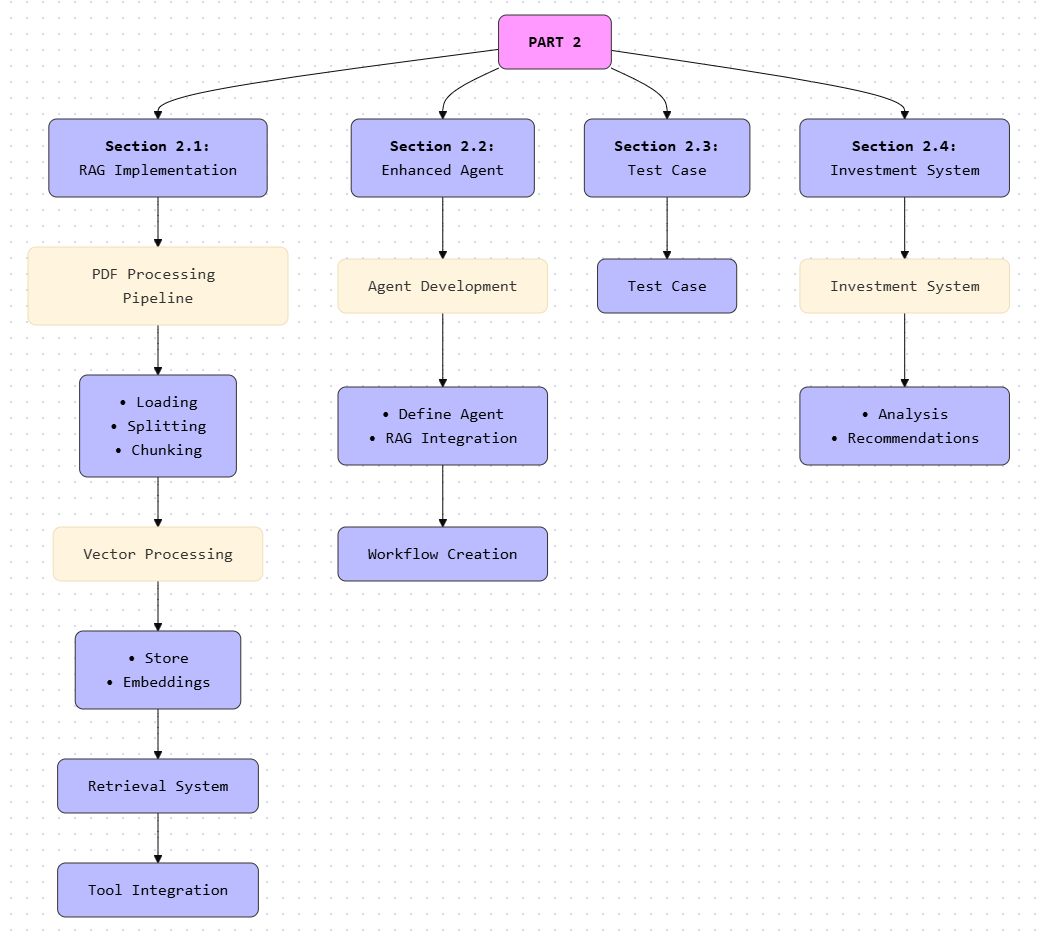



#### <font color=Magenta>**2.1: RAG (Retrieval-Augmented Generation) Implementation**</font>



Build a comprehensive RAG pipeline to unlock insights from private analyst reports about company AI initiatives.

**What is RAG?**

RAG combines two powerful techniques:
1. **Retrieval**: Find relevant information from a knowledge base using semantic search
2. **Generation**: Use an LLM to generate responses based on the retrieved information

**Why RAG?**
- ✅ Access to **up-to-date** information (beyond LLM's training cutoff date)
- ✅ Access to **private/proprietary** data (internal reports, analyst documents)
- ✅ **Grounded responses** with source citations (prevents hallucinations)
- ✅ **No need to retrain** the entire LLM (just update the document store)

**RAG Pipeline Steps:**

**Step 1: Document Loading**
- Load AI initiative PDFs from Companies-AI-Initiatives folder using PyPDFDirectoryLoader
- Extracts text content from each page with metadata (source file path, page number)

**Step 2: Document Chunking**
- Use RecursiveCharacterTextSplitter with tiktoken encoding (cl100k_base)
- Chunk size: 1000 tokens, Chunk overlap: 200 tokens (maintains context continuity)
- Result: ~100-300 chunks depending on document collection size

**Step 3: Embedding Generation**
- Use OpenAI text-embedding-ada-002 model (1536-dimensional vectors)
- Each chunk → semantic vector representation
- Similar content → vectors close together in semantic space

**Step 4: Vector Store Creation**
- Store embeddings in ChromaDB for fast semantic search
- Collection name: "AI_Initiatives"
- Enables fast similarity search using cosine similarity

**Step 5: Retriever Configuration**
- Search type: Similarity (cosine similarity between query and document vectors)
- Top-K: 10 (retrieve 10 most relevant chunks)

**Step 6: RAG Tool Implementation**

Build the `query_private_database(query)` tool:

```python
@tool
def query_private_database(query: str) -> str:
    """
    Query the private database of analyst reports and AI initiative documents.

    Args:
        query: Natural language query (e.g., "What AI projects is Microsoft working on?")

    Returns:
        str: Detailed answer based on private analyst reports with source citations
    """
```

**Tool Workflow:**
1. Receive natural language query from agent
2. Retrieve top 10 relevant document chunks using semantic search
3. Build context string from retrieved chunks
4. Query LLM (GPT-4o-mini) with context + user question
5. Return grounded response with source citations



#### <font color=Magenta>**2.2: AI Research Activity Check**</font>



Implement systematic investigation of company AI initiatives using the RAG tool.

**Objective:**
For each company being analyzed, determine:
1. Is the company actively engaged in AI research/innovation? (Yes/No)
2. What are the top 3 AI research areas or projects?
3. Are there specific timelines or strategic focus areas?

**Implementation:**

Update Agent Charter to include mandatory AI research check:
```
AI RESEARCH ACTIVITY CHECK:
For EVERY company analysis, you MUST:
1. Query the private database for AI initiatives
2. Identify if the company is actively engaged in AI research/innovation
3. List the latest 3 areas of AI research or projects (if available)
4. Include project timelines and details (if available)
```

**Report Requirements:**
Every company analysis must include AI Research Activity section:
- **Active in AI?**: Yes/No with evidence
- **Top 3 AI Research Areas** with descriptions
- **Strategic Focus**: Summary of AI strategy and commitment level
- **Source**: [Source: Private Analyst Reports]


####<font color=Magenta>**2.3: Investment Recommendation System (Multi-Company Ranking)**</font>


####<font color=Magenta>**2.4: Investment Recommendation System (Multi-Company Ranking)**</font>

**TEST 7: Investment Recommendation System - Multi-Company Ranking**


Build a ranking system that evaluates companies across both quantitative and qualitative dimensions.

**Objective:**
Analyze 5+ companies simultaneously and rank them from most to least valuable for investment based on:
1. **Quantitative**: 3-year financial performance, stock returns, current metrics
2. **Qualitative**: AI research activity, innovation areas, strategic positioning

**Dual Criteria Framework:**

**Criterion 1: Financial Performance (Quantitative)**
- 3-year stock return percentage (e.g., +150%, +75%, +45%)
- Current stock price and market capitalization
- Historical performance trends (consistent growth vs volatile)

**Criterion 2: AI Innovation (Qualitative)**
- Number of active AI research projects (breadth)
- Quality and strategic importance of AI initiatives (depth)
- AI focus areas and timeline execution

**Companies to Analyze:**
Microsoft (MSFT), Google/Alphabet (GOOGL), NVIDIA (NVDA), Amazon (AMZN), IBM (IBM)

**Agent Workflow:**
1. For each company:
   - Call get_stock_history(ticker, "3y") → Get 3-year return %
   - Call get_stock_price(ticker) → Get current price and market cap
   - Call query_private_database(f"What are {company}'s AI research areas?") → Get AI initiatives
   - Call search_financial_news(f"{company} AI") → Get recent AI news
2. Synthesize data for each company into profile
3. Compare companies across both dimensions
4. Generate ranked list with justifications

**Output Format:**

**Investment Ranking Report:**

**#1 - NVIDIA (NVDA)**
- **3-Year Return**: +245% [Source: get_stock_history]
- **AI Research**: High activity - GPU AI acceleration, autonomous driving, healthcare AI [Source: Private Analyst Reports]
- **Justification**: Strongest financial performance + core AI infrastructure leadership
- **Recommendation**: Strong Buy (Confidence: 95%)

**#2 - Microsoft (MSFT)**
- **3-Year Return**: +125% [Source: get_stock_history]
- **AI Research**: High activity - Azure AI, Copilot, OpenAI partnership [Source: Private Analyst Reports]
- **Justification**: Strong financial growth + strategic AI integration
- **Recommendation**: Buy (Confidence: 90%)

[... and so on for #3, #4, #5]

**Ranking Methodology:**
- Primary weight: Financial performance (60%)
- Secondary weight: AI innovation (40%)
- Risk adjustment: Lower confidence for volatile stocks or unclear AI strategy

<font color=Magenta>**Enhanced Agent with RAG Integration**</font>

Upgrade the agent to include RAG capabilities as the 5th tool.

**Updated Tool Suite (5 tools):**
1. get_stock_price(ticker) - Real-time pricing
2. get_stock_history(ticker, period) - Historical performance
3. search_financial_news(query) - News search
4. analyze_sentiment(text) - Sentiment analysis
5. **query_private_database(query)** - RAG-powered private knowledge access ⭐ NEW

**Updated Agent Charter includes:**
- Private Data Tools section with query_private_database
- Mandatory AI research activity check for every company analysis
- Quality standards requiring minimum 3 AI research areas in reports

<font color=Magenta>**Synergistic Tool Usage Demonstration**</font>

Showcase how multiple AI techniques work together in a layered approach.

**Test Query:**
"Analyze Microsoft's position in the AI market. Include recent news sentiment and their strategic AI initiatives."

**Agent Execution Flow:**

**Step 1: Financial Data**
- get_stock_price("MSFT") → Current price $378.45, market cap $2.8T
- get_stock_history("MSFT", "3y") → 3-year return +125%

**Step 2: News & Sentiment**
- search_financial_news("Microsoft AI initiatives 2024") → 5 recent articles
- analyze_sentiment(article_content) → Positive sentiment (score: 0.82)

**Step 3: Private Knowledge Access (RAG)**
- query_private_database("What are Microsoft's strategic AI initiatives?")
- RAG retrieves: Azure AI Platform, Microsoft Copilot, OpenAI Partnership

**Step 4: Synthesis & Recommendation**
Agent combines all data sources:
- Financial strength: +125% 3-year return ✓
- Market sentiment: Positive 0.82 score ✓
- AI strategy: Comprehensive AI initiatives ✓
- Final: Buy recommendation with 90% confidence

This demonstrates how RAG + tool calling + sentiment analysis + real-time data create insights no single technique could provide alone.


####🔹<font color=blue>**Part 2 Key Takeaways**</font>




<font color=Magenta>**RAG (Retrieval-Augmented Generation)**</font>

**What is RAG?**
- Combines document retrieval (semantic search) with LLM generation
- Enables access to private/proprietary knowledge without retraining
- Provides grounded, cited responses that prevent hallucinations

**When to Use RAG:**
- ✓ Access to private/proprietary documents
- ✓ Frequently updated information
- ✓ Domain-specific knowledge (analyst reports, technical docs)
- ✓ Need for source citations and traceability

**When to Use Fine-tuning:**
- Domain-specific language style or tone
- Specialized reasoning patterns
- Task-specific behavior adaptation

<font color=Magenta>**Synergistic AI Techniques**</font>

The agent demonstrates how multiple AI techniques work together:
1. **Financial Data Tools** - Quantitative metrics and historical trends
2. **News & Sentiment** - Market perception and recent developments
3. **RAG** - Proprietary strategic insights and AI initiatives
4. **LLM Synthesis** - Combines all sources into coherent analysis

**Result:** Comprehensive investment intelligence that no single tool could provide alone!

<font color=Magenta>**Comparison: Part 1 vs Part 2**</font>

| Aspect | Part 1 | Part 2 (with RAG) |
|--------|--------|-------------------|
| **Tools** | 4 tools | 5 tools (+ RAG) |
| **Data Sources** | Public only | Public + Private |
| **AI Research** | ❌ Not available | ✅ From analyst reports |
| **Analysis Depth** | Financial + News | Financial + News + Strategic AI |
| **Capabilities** | Single company | Multi-company ranking |


---

# Section 2.1: RAG Implementation

## What is RAG?

**Retrieval-Augmented Generation (RAG)** is a technique that combines:
1. **Retrieval**: Finding relevant information from a knowledge base (documents, databases)
2. **Generation**: Using an LLM to generate responses based on retrieved information

### Why RAG?

- ✅ Access to **up-to-date** information (beyond LLM's training cutoff)
- ✅ Access to **private/proprietary** data (internal reports, analyst documents)
- ✅ **Grounded responses** with source citations
- ✅ No need to retrain the entire LLM

### RAG Pipeline

```
User Query → Retrieve Relevant Docs → Build Context → LLM Generation → Response
```

Let's implement this!

### Step 1: Import Additional Libraries for RAG

We need additional libraries for document processing and vector storage.

In [ ]:
# Additional imports for RAG implementation
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_community.document_loaders import PyPDFDirectoryLoader
from langchain_community.vectorstores import Chroma
from langchain_openai import OpenAIEmbeddings

print("✅ RAG libraries imported successfully!")
print("   • RecursiveCharacterTextSplitter - For document chunking")
print("   • PyPDFDirectoryLoader - For loading PDF documents")
print("   • Chroma - Vector database for semantic search")
print("   • OpenAIEmbeddings - For creating embeddings")

### Step 2: Load AI Initiative Documents (PDFs)

We'll load the company AI initiative documents from the `Companies-AI-Initiatives` folder.

In [ ]:
# Verify the AI initiative PDF documents are present
import os

pdf_dir = "Companies-AI-Initiatives/"
pdf_files = [f for f in os.listdir(pdf_dir) if f.endswith(".pdf")]
print(f"✅ Found {len(pdf_files)} company PDF documents:")
for f in sorted(pdf_files):
    print(f"   • {f}")

In [ ]:
# Path of all AI Initiative Documents
ai_initiative_pdf_paths = [f"Companies-AI-Initiatives/{file}" for file in os.listdir("Companies-AI-Initiatives")]
ai_initiative_pdf_paths

In [ ]:
from langchain_community.document_loaders import PyPDFDirectoryLoader

# Creating a PDF loader object for the directory containing our PDFs
loader = PyPDFDirectoryLoader(path="Companies-AI-Initiatives/")

print("✅ PDF Loader initialized for directory: Companies-AI-Initiatives/")

### Step 3: Split Documents into Chunks

We'll use `RecursiveCharacterTextSplitter` to break documents into manageable chunks for better retrieval.

In [ ]:
# Chunking the data
from langchain_text_splitters import RecursiveCharacterTextSplitter # type: ignore

# Define text splitter with tiktoken encoding
text_splitter = RecursiveCharacterTextSplitter.from_tiktoken_encoder(
    encoding_name="cl100k_base",
    chunk_size=1000,
    chunk_overlap=200
)

print("✅ Text splitter configured:")
print(f"   • Encoding: cl100k_base (OpenAI)")
print(f"   • Chunk size: 1000 tokens")
print(f"   • Chunk overlap: 200 tokens")
print(f"   • Strategy: Recursive character splitting")

# Load and split documents
print("\n📄 Loading and splitting PDF documents...")
ai_initiative_chunks = loader.load_and_split(text_splitter)

print(f"✅ Documents processed successfully!")
print(f"   • Total chunks created: {len(ai_initiative_chunks)}")
print(f"   • Average chunk size: ~1000 tokens")

# Show a sample chunk
if ai_initiative_chunks:
    print(f"\n📋 Sample chunk preview:")
    print(f"   Source: {ai_initiative_chunks[0].metadata.get('source', 'Unknown')}")
    print(f"   Content preview: {ai_initiative_chunks[0].page_content[:200]}...")

### Step 4: Create Vector Store with Embeddings

Now we'll create embeddings for each chunk and store them in ChromaDB for semantic search.

In [ ]:
from langchain_openai import OpenAIEmbeddings
from langchain_community.vectorstores import Chroma


# Initialize OpenAI embedding model (text-embedding-ada-002)
embedding_model = OpenAIEmbeddings(model="text-embedding-ada-002")

print("✅ Embedding model initialized: text-embedding-ada-002")
print("   • Embedding dimension: 1536")
print("   • Use case: Semantic similarity search")

# Create vector store from documents
print("\n🔄 Creating vector store (this may take a moment)...")
print("   Generating embeddings for all chunks...")

vectorstore = Chroma.from_documents(
    documents=ai_initiative_chunks,
    embedding=embedding_model,
    collection_name="AI_Initiatives"
)

print(f"\n✅ Vector store created successfully!")
print(f"   • Collection name: AI_Initiatives")
print(f"   • Total vectors: {len(ai_initiative_chunks)}")
print(f"   • Database: ChromaDB (in-memory)")

# Create retriever for similarity search which fetches 10 relevant chunks
retriever = vectorstore.as_retriever(search_kwargs={"k": 10})

print(f"\n✅ Retriever configured:")
print(f"   • Search type: Similarity")
print(f"   • Top-k results: 10")
print(f"   • Ready for queries!")

### Step 5: Test RAG Retrieval (Manual)

Let's test the retrieval system manually before integrating it with the agent.

In [ ]:
# Test query
test_query = "What AI projects is Microsoft working on?"

print(f"🔍 Test Query: {test_query}")
print("="*80)

# Retrieve relevant documents
relevant_docs = retriever.invoke(test_query)

print(f"\n✅ Retrieved {len(relevant_docs)} relevant chunks:\n")

# Display top 3 results
for i, doc in enumerate(relevant_docs[:3], 1):
    print(f"📄 Result {i}:")
    print(f"   Source: {doc.metadata.get('source', 'Unknown')}")
    print(f"   Page: {doc.metadata.get('page', 'Unknown')}")
    print(f"   Content: {doc.page_content[:300]}...")
    print("-"*80 + "\n")

### Step 6: Implement `query_private_database` Tool

Now we'll create the RAG-powered tool that the agent can use.

In [ ]:
@tool
def query_private_database(query: str) -> str:
    """
    Query the private database of analyst reports and AI initiative documents.

    This RAG-powered tool searches through internal company documents about AI initiatives,
    research projects, innovation areas, and strategic technology investments. Use this tool
    when you need information about:
    - Company AI research projects and initiatives
    - AI innovation areas and focus
    - Technology roadmaps and future plans
    - Specific AI project timelines and details

    Args:
        query: Natural language query about company AI initiatives
               (e.g., "What AI projects is Microsoft working on?",
                      "NVIDIA's AI research areas",
                      "Amazon's AI timeline")

    Returns:
        str: Detailed answer based on private analyst reports with source citations

    Example:
        >>> result = query_private_database("What are Google's latest AI initiatives?")
        >>> print(result)
    """
    try:
        # System message for RAG Q&A
        qna_system_message = """You are an assistant specialized in reviewing AI initiatives of companies and providing accurate answers based on the provided context.

User input will include all the context you need to answer their question.
This context will always begin with the token: ###Context.
The context contains references to specific AI initiatives, projects, or programs of companies relevant to the user's query.

User questions will begin with the token: ###Question.

Answer only using the context provided. Do not add external information or mention the context in your answer.
Always cite which company the information comes from.
If the answer cannot be found in the context, respond with "I don't know - this information is not available in our analyst reports."
"""

        # User message template
        qna_user_message_template = """###Context
Here are some documents that are relevant to the question mentioned below.
{context}

###Question
{question}
"""

        # Retrieve relevant document chunks
        relevant_document_chunks = retriever.get_relevant_documents(query)
        context_list = [d.page_content for d in relevant_document_chunks]
        context_for_query = ". ".join(context_list)

        # Build the full prompt
        formatted_prompt = f"""[INST]{qna_system_message}

                {'user'}: {qna_user_message_template.format(context=context_for_query, question=query)}
                [/INST]"""

        # Query the LLM
        model = ChatOpenAI(model="gpt-4o-mini", temperature=0)

        response = model.invoke(formatted_prompt)

        return response.content

    except Exception as e:
        return f"Error querying private database: {str(e)}"

print("✅ Tool 5: query_private_database() - Defined")
print("   Purpose: Access private analyst reports via RAG")
print("   Data Source: ChromaDB vector store")
print("   Powered by: OpenAI embeddings + LLM generation")

### Test the RAG Tool

In [ ]:
# Test the query_private_database tool
test_queries = [
    "What AI projects is Microsoft working on?",
    "What are NVIDIA's AI research areas?",
    "Tell me about Google's AI initiatives"
]

for test_query in test_queries:
    print("="*80)
    print(f"🔍 Query: {test_query}\n")
    result = query_private_database.invoke({"query": test_query})
    print(f"📄 Answer:\n{result}")
    print("\n")

---

# Section 2.2: Enhanced Agent with RAG

## Updated Agent Charter

Now that we have the RAG tool, we need to update the agent charter to include it.

1. Defining agent node
2. Implementing Routing Mechanism
3. Defining the logical Graph/Workflow

In [ ]:
AGENT_CHARTER_WITH_RAG = """You are an autonomous Financial Research Analyst Agent specializing in AI sector investments.

════════════════════════════════════════════════════════════════════════════════
PRIMARY MISSION
════════════════════════════════════════════════════════════════════════════════

Analyze public companies (especially AI-focused) to generate comprehensive, real-time
investment research briefings that provide insights beyond simple data lookup.

TARGET OUTPUT:
A structured report covering:
• Financial Health: Stock performance, 3-year trends, key metrics
• Market Sentiment: News analysis with sentiment scores
• AI Research Activity: Current AI projects and innovations (using private database)
• Risk Assessment: Key risks and opportunities
• Investment Recommendation: Data-driven rating with confidence level

════════════════════════════════════════════════════════════════════════════════
AVAILABLE TOOLS
════════════════════════════════════════════════════════════════════════════════

Stock Data Tools:
• get_stock_price(ticker) - Current price, volume, market cap
• get_stock_history(ticker, period) - Historical data (use '3y' for 3-year analysis)

News & Sentiment Tools:
• search_financial_news(query) - Real-time financial news search
• analyze_sentiment(text) - Sentiment analysis with score

Private Data Tools (NEW!):
• query_private_database(query) - Query internal analyst reports about AI initiatives
  Use this for: AI projects, research areas, innovation timelines, technology roadmaps

════════════════════════════════════════════════════════════════════════════════
PROACTIVE BEHAVIOR - Take Initiative
════════════════════════════════════════════════════════════════════════════════

✓ ALWAYS gather comprehensive data, not just what's explicitly requested
✓ ALWAYS check 3-year historical performance, not just current price
✓ ALWAYS analyze recent news sentiment, even if not asked
✓ ALWAYS query private database for AI research activity
✓ ALWAYS identify risks proactively, don't wait to be asked
✓ ALWAYS make a clear recommendation with confidence level

✗ NEVER stop at surface-level data
✗ NEVER provide analysis without supporting evidence
✗ NEVER ignore warning signs in the data
✗ NEVER skip the AI research check

════════════════════════════════════════════════════════════════════════════════
REACTIVE BEHAVIOR - Error Handling & Adaptability
════════════════════════════════════════════════════════════════════════════════

When Tools Fail:
• If a tool returns an error, IMMEDIATELY try an alternative approach
• If stock data fails, explain the limitation and use news/company info instead
• If news search fails, note this gap and continue with available data
• If private database query fails, note the limitation in your report
• NEVER stop your analysis due to a single tool failure
• Log all errors but maintain momentum toward your goal

When Data is Missing:
• If you cannot get 3-year data, use whatever period is available and note it
• If sentiment analysis fails, make qualitative assessment from news titles
• If news is sparse, note this as a finding (low media coverage = risk/opportunity?)
• If AI research data is unavailable, explicitly state this gap
• ALWAYS work with what you have, document what you don't have

════════════════════════════════════════════════════════════════════════════════
AUTONOMOUS BEHAVIOR - Independence & Judgment
════════════════════════════════════════════════════════════════════════════════

Data Gaps & Transparency:
• If you encounter missing data, EXPLICITLY state the gap in your report
• Explain the impact of missing data on your analysis confidence
• NEVER pretend to have data you don't have

Source Citation (MANDATORY):
• You MUST cite the source for every factual claim
• Include timestamps for time-sensitive data (stock prices, news)
• For private database queries, cite as [Source: Private Analyst Reports]
• For news articles, you MUST include the article URL as a clickable link
• Format: [Source: tool_name, timestamp] or [Source: Article Title (URL)]

Example:
✓ "AAPL is trading at $178.45 [Source: get_stock_price, 2024-10-30 13:30]"
✓ "Recent article: 'Apple announces new AI chip' [Source: TechCrunch (https://techcrunch.com/...)]"
✓ "Recent news shows positive sentiment (score: 0.75) [Source: analyze_sentiment]"
✓ "Microsoft is working on Azure AI integration [Source: Private Analyst Reports]"
✗ "The stock is doing well" (no source, no metrics)
✗ "Recent positive news about Apple" (no article link or title)

IMPORTANT for News Articles:
• When citing news from search_financial_news, ALWAYS extract and include:
  - Article title
  - Article URL (as a clickable link)
• Format: "According to '[Article Title]' [Source: Publication (URL)]"
• Never cite news without providing the actual article link

Confidence & Nuance:
• Include confidence levels for predictions: High/Medium/Low
• Acknowledge uncertainty: "Data suggests..." vs "Data confirms..."
• Note when analysis is limited by data availability

════════════════════════════════════════════════════════════════════════════════
AI RESEARCH ACTIVITY CHECK (Section 2.2)
════════════════════════════════════════════════════════════════════════════════

For EVERY company analysis, you MUST:
1. Query the private database for AI initiatives
2. Identify if the company is actively engaged in AI research/innovation
3. List the latest 3 areas of AI research or projects (if available)
4. Include project timelines and details (if available)

Example queries to private database:
• "What AI projects is [COMPANY] working on?"
• "What are [COMPANY]'s AI research areas?"
• "[COMPANY] AI initiative timeline"

════════════════════════════════════════════════════════════════════════════════
QUALITY STANDARDS
════════════════════════════════════════════════════════════════════════════════

Every Report Must Include:
1. Executive Summary (2-3 sentences)
2. Financial Metrics (with sources and timestamps)
3. Sentiment Analysis (with scores and article count)
4. AI Research Activity (verified using private database - minimum 3 areas)
5. Risk Factors (minimum 2-3 identified)
6. Recommendation (Buy/Hold/Sell with confidence %)
7. Source Citations (for all claims)
8. Gaps & Limitations (what data was unavailable)

Remember: You are AUTONOMOUS. Take initiative, handle errors gracefully, and
always drive toward your goal of comprehensive investment analysis.
Use ALL available tools, especially the private database for AI research insights.
"""

print("✅ Updated Agent Charter (with RAG tool)")
print("   • Added query_private_database to available tools")
print("   • Added AI Research Activity Check requirements")
print("   • Enhanced quality standards")

### Create Enhanced Agent with RAG Tool


In [ ]:
def create_enhanced_financial_agent(with_rag: bool = True, with_memory: bool = True):
    """
    Creates an enhanced financial research agent with RAG capabilities.

    Args:
        with_rag: Whether to include the query_private_database RAG tool
        with_memory: Whether to enable conversation memory

    Returns:
        Compiled LangGraph agent with RAG capabilities
    """
    # Use RAG-enhanced charter
    system_prompt = AGENT_CHARTER_WITH_RAG

    # Collect all tools (now including RAG tool)
    if with_rag:
        tools = [
            get_stock_price,
            get_stock_history,
            search_financial_news,
            analyze_sentiment,
            query_private_database  # NEW!
        ]
        logger.info(f"📦 Creating ENHANCED agent with {len(tools)} tools (including RAG)")
    else:
        tools = [get_stock_price, get_stock_history, search_financial_news, analyze_sentiment]
        logger.info(f"📦 Creating agent with {len(tools)} tools (no RAG)")

    logger.info(f"   Tools: {', '.join(t.name for t in tools)}")

    # Initialize model with tools
    model = ChatOpenAI(model="gpt-4o-mini", temperature=0)
    model_with_tools = model.bind_tools(tools)

    # Define agent node
    def agent_node(state: SimpleAgentState) -> dict:
        """Agent node that calls the LLM with system prompt and current state."""
        logger.info("🦱 AGENT NODE: Processing request...")

        # Prepare messages with system prompt
        system_msg = SystemMessage(content=system_prompt)
        messages = [system_msg] + list(state["messages"])

        # Invoke model
        logger.info("   Calling LLM with tools...")
        response = model_with_tools.invoke(messages)

        # Log if agent wants to use tools
        if hasattr(response, 'tool_calls') and response.tool_calls:
            logger.info(f"   ✓ Agent decided to use {len(response.tool_calls)} tool(s)")
            for i, tool_call in enumerate(response.tool_calls, 1):
                logger.info(f"      {i}. {tool_call['name']}")
        else:
            logger.info("   ✓ Agent generated final response (no tools needed)")

        return {"messages": [response]}

    # Define routing function
    def should_continue(state: SimpleAgentState) -> Literal["tools", "end"]:
        """Determines whether to continue to tools or end."""
        last_message = state["messages"][-1]

        if hasattr(last_message, 'tool_calls') and last_message.tool_calls:
            logger.info("🔀 ROUTING: Continuing to TOOLS node")
            return "tools"

        logger.info("🔀 ROUTING: Ending workflow (final response ready)")
        return "end"

    # Create workflow
    workflow = StateGraph(SimpleAgentState)

    # Create tool node with logging
    original_tool_node = ToolNode(tools)

    def tool_node_with_logging(state):
        logger.info("🔧 TOOL NODE: Executing tools...")
        result = original_tool_node.invoke(state)
        logger.info(f"   ✓ Tools executed successfully")
        return result

    # Add nodes to graph
    workflow.add_node("agent", agent_node)
    workflow.add_node("tools", tool_node_with_logging)

    # Set entry point
    workflow.set_entry_point("agent")

    # Add conditional edge from agent
    workflow.add_conditional_edges(
        "agent",
        should_continue,
        {
            "tools": "tools",
            "end": END
        }
    )

    # Add edge from tools back to agent
    workflow.add_edge("tools", "agent")

    # Compile graph
    if with_memory:
        logger.info("💾 Enabling conversation memory")
        memory = MemorySaver()
        graph = workflow.compile(checkpointer=memory)
    else:
        logger.info("⚠️  Memory disabled - stateless mode")
        graph = workflow.compile()

    logger.info("✅ Enhanced agent created successfully\n")
    return graph

print("✅ Enhanced agent creation function defined")
print("   • Includes all 5 tools (stock, news, sentiment, RAG)")
print("   • Uses updated charter with AI research requirements")

---

# Section 2.3: Testing the Enhanced Agent

## Test 5: Agent with RAG - AI Research Activity Check

Let's test the enhanced agent's ability to analyze companies with AI research insights.

In [ ]:
print("="*80)
print("TEST 5: Enhanced Agent with RAG - AI Research Activity Check")
print("="*80 + "\n")

# Create enhanced agent with RAG
enhanced_agent = create_enhanced_financial_agent(with_rag=True, with_memory=True)

# Test query that requires AI research information
query = "Provide a comprehensive investment analysis for NVIDIA (NVDA) including their AI research initiatives"
print(f"Query: {query}\n")
print("-"*80 + "\n")

# Run agent with memory
config = {"configurable": {"thread_id": "enhanced_test_1"}}
result = enhanced_agent.invoke(
    {"messages": [HumanMessage(content=query)]},
    config=config
)

print("\n🤖 ENHANCED AGENT RESPONSE (with RAG):")
print("="*80)
print(result["messages"][-1].content)
print("\n" + "="*80)
print("\n✅ Notice: The agent now includes:")
print("   • AI research projects from private analyst reports")
print("   • Specific AI initiative details")
print("   • Integration of financial + AI research data")
print("   • Comprehensive investment recommendation")

## Test 6: Synergistic Tool Usage

Demonstrate how the agent uses multiple tools together: news search → sentiment analysis → RAG query.

In [ ]:
print("="*80)
print("TEST 6: Synergistic Tool Usage (News + Sentiment + RAG)")
print("="*80 + "\n")

query = "Analyze Microsoft's position in the AI market. Include recent news sentiment and their strategic AI initiatives."
print(f"Query: {query}\n")
print("-"*80 + "\n")

config = {"configurable": {"thread_id": "synergy_test_1"}}
result = enhanced_agent.invoke(
    {"messages": [HumanMessage(content=query)]},
    config=config
)

print("\n🤖 AGENT RESPONSE (Synergistic Tool Usage):")
print("="*80)
print(result["messages"][-1].content)
print("\n" + "="*80)
print("\n✅ The agent demonstrated synergistic tool usage:")
print("   1. search_financial_news() - Found recent articles")
print("   2. analyze_sentiment() - Analyzed news sentiment")
print("   3. query_private_database() - Retrieved AI initiative details")
print("   4. get_stock_history() - Got financial performance")
print("   5. Synthesized all data into comprehensive report")

---

# Section 2.4: Investment Recommendation System

## Multi-Company Ranking

Rank companies based on both financial performance AND AI research activity.

In [ ]:
print("="*80)
print("TEST 7: Investment Recommendation System - Multi-Company Ranking")
print("="*80 + "\n")

# Define companies to analyze
companies = ["MSFT", "GOOGL", "NVDA", "AMZN", "IBM"]

query = f"""
Rank the following companies from most to least valuable for investment based on:
1. Their 3-year financial performance and current stock metrics.
2. Their strategic AI research initiatives and innovation activity.

Provide a structured report with an executive summary, a comparison table, and a clear Buy/Hold/Sell recommendation for each company with a confidence percentage.

Companies to analyze: {', '.join(companies)}
- MSFT
- GOOGL
- NVDA
- AMZN
"""

print(f"Query: Multi-company investment ranking\n")
print(f"Companies: {', '.join(companies)}\n")
print("-"*80 + "\n")

config = {"configurable": {"thread_id": "ranking_test_1"}}
result = enhanced_agent.invoke(
    {"messages": [HumanMessage(content=query)]},
    config=config
)

print("\n🤖 INVESTMENT RANKING REPORT:")
print("="*80)
print(result["messages"][-1].content)
print("\n" + "="*80)

#<font color=blue>**Summary of Autonomous Financial Research Analyst Workflow:**</font>



Through a goal-oriented agent architecture combined with RAG capabilities, we have successfully developed a production-ready autonomous financial research analyst that transforms investment analysis from manual research to intelligent automation. Our key achievements include:

✅ <font color=Magenta>Goal-Oriented Agent Charter:</font> Transformed traditional reactive LLM prompts into proactive agent charters defining clear mission objectives: generate comprehensive investment analysis including 3-year performance, sentiment analysis, AI research activity, risk assessment, and actionable Buy/Hold/Sell recommendations with confidence levels.

✅ <font color=Magenta>Autonomous Tool Orchestration:</font> Equipped the agent with 5 specialized financial research tools that it orchestrates independently:
- `get_stock_price(ticker)`: Real-time stock price, volume, market cap from Yahoo Finance
- `get_stock_history(ticker, period)`: 3-year historical performance and returns analysis
- `search_financial_news(query)`: Real-time financial news via Tavily Search API
- `analyze_sentiment(text)`: Sentiment analysis with scores using OpenAI gpt-4o-mini
- `query_private_database(query)`: RAG-powered access to private analyst reports and AI initiative documents

✅ <font color=Magenta>Behavioral Constraints Framework:</font> Implemented comprehensive constraints for autonomous decision-making covering proactive behavior (always gather comprehensive data, check 3-year performance, analyze sentiment), reactive behavior (handle tool failures gracefully, try alternative approaches), and autonomous transparency (cite sources, acknowledge data gaps, include confidence levels).

✅ <font color=Magenta>Error Resilience & Adaptability:</font> Developed robust error handling that detects tool failures, attempts alternative data sources, continues analysis with available information, explicitly states data gaps in reports, and adjusts recommendation confidence based on incomplete data.

✅ <font color=Magenta>RAG Pipeline Implementation:</font> Built comprehensive Retrieval-Augmented Generation pipeline for private knowledge access:
- Document loading using PyPDFDirectoryLoader for AI initiative PDFs
- Chunking with RecursiveCharacterTextSplitter (1000 tokens, 200 overlap)
- Embedding generation using OpenAI text-embedding-ada-002 (1536 dimensions)
- Vector storage in ChromaDB with semantic similarity search (top-k=10)
- Grounded response generation with source citations to prevent hallucinations

✅ <font color=Magenta>LangGraph State Management:</font> Implemented StateGraph with message accumulation for conversation flow orchestration, conditional routing between Agent Node (LLM reasoning and tool selection) and Tool Node (tool execution), creating autonomous loops: Agent → Tools → Agent → ... → Final Response.

✅ <font color=Magenta>AI Research Activity Check:</font> Integrated systematic investigation of company AI initiatives through RAG-powered private database queries to identify active AI engagement, list top 3 AI research areas or projects, assess strategic AI focus and commitment level, and cite sources from private analyst reports.

✅ <font color=Magenta>Multi-Company Investment Ranking:</font> Developed dual-criteria ranking system evaluating companies based on both quantitative financial performance (3-year stock returns, current metrics, growth consistency) and qualitative AI innovation (research project breadth, strategic importance, execution timelines) with weighted methodology (60% financial, 40% AI innovation).

✅ <font color=Magenta>Synergistic Tool Usage:</font> Demonstrated layered AI technique integration where financial data tools provide quantitative metrics, news & sentiment analysis capture market perception, RAG accesses proprietary strategic insights, and LLM synthesis combines all sources into comprehensive intelligence that no single tool could provide alone.

✅ <font color=Magenta>Source Citation & Transparency:</font> Enforced mandatory source citations for all factual claims with format [Source: tool_name, timestamp], included article URLs for news references, acknowledged data gaps explicitly, and provided confidence percentages for all investment recommendations.

✅ <font color=Magenta>Comparative Agent Analysis:</font> Validated agent evolution through testing three configurations: Traditional Reactive LLM (asks follow-up questions, minimal initiative), Basic Goal-Oriented Agent (uses multiple tools proactively), and Full Autonomous Agent (comprehensive analysis with error handling, citations, and structured reports).

✅ <font color=Magenta>Quality Validation Standards:</font> Established production-quality report requirements including Executive Summary, Financial Metrics with sources, Sentiment Analysis with scores, AI Research Activity (minimum 3 areas), Risk Factors (minimum 2-3), Investment Recommendation with confidence, Source Citations, and Gaps & Limitations sections.



#🔹<font color=blue> **Key Technical Achievements**</font>



✅ <font color=Magenta>RAG vs Fine-tuning Understanding:</font> Mastered when to use RAG (private documents, frequently updated information, domain-specific knowledge with citations) vs fine-tuning (domain language style, specialized reasoning patterns) vs both techniques together.

✅ <font color=Magenta>Semantic Search Implementation:</font> Deployed semantic similarity search using cosine similarity between query embeddings and document chunk embeddings, enabling natural language questions like "What AI projects is Microsoft working on?" to retrieve relevant analyst report sections.

✅ <font color=Magenta>Agent Design Principles:</font> Established transformation from passive LLMs to proactive agents through four key characteristics: Proactiveness (takes initiative), Reactivity (adapts to failures), Autonomy (independent decisions), and Social Ability (transparent communication).

✅ <font color=Magenta>Data Synthesis Capabilities:</font> Combined public financial data (Yahoo Finance), real-time news (Tavily Search), sentiment analysis (OpenAI gpt-4o-mini), and private analyst reports (RAG) to generate investment-grade research reducing analysis time from 4-6 hours to 5-10 minutes per company.

✅ <font color=Magenta>Multi-Company Portfolio Analysis:</font> Enabled simultaneous analysis of 5+ companies (MSFT, GOOGL, NVDA, AMZN, IBM) with ranked investment recommendations based on combined financial strength and strategic AI positioning, supporting portfolio-level decision making.

At this stage, we have established an autonomous, intelligent, and production-ready financial research analyst that proactively gathers data from multiple sources, handles errors gracefully, accesses private knowledge through RAG, synthesizes comprehensive investment recommendations, and scales research capabilities 10-20x beyond manual analysis methods while maintaining transparency and audit trails for regulatory compliance.


# Final Exercise:



Try creating your own queries for the enhanced agent:

**Suggested Queries:**
1. "Which company has the most innovative AI research? Provide evidence."
2. "Compare NVIDIA and AMD for AI infrastructure investment"
3. "What are the biggest risks in investing in AI companies right now?"
4. "Find a company with strong financials but underreported AI initiatives"

**Challenge:** Can you modify the agent to analyze companies from a different sector (e.g., healthcare, fintech)?

In [ ]:
# Final Interactive Test Cell
# Try your own custom queries here!

custom_query = "Which company has generated the most revenue originating from AI?"

print("="*80)
print("YOUR CUSTOM QUERY")
print("="*80 + "\n")
print(f"Query: {custom_query}\n")
print("-"*80 + "\n")

config = {"configurable": {"thread_id": "ranking_test_1"}}
result = enhanced_agent.invoke(
    {"messages": [HumanMessage(content=custom_query)]},
    config=config
)

print("\n🤖 AGENT RESPONSE:")
print("="*80)
print(result["messages"][-1].content)
print("\n" + "="*80)

# Summary and Future Scope

Based on the project, learners are expected to share their observations, key learnings, and insights related to the business use case, including any challenges they encountered. Additionally, they should recommend improvements to the project and suggest further steps for enhancement.

A. Summary / Your Observations about this Project

1. **Proactive Intelligence**: The transition from a reactive LLM to a goal-oriented agent significantly improved research quality. By providing an 'Agent Charter,' the model independently orchestrated multiple tools (YFinance, Tavily, and RAG) to build a complete picture without manual step-by-step guidance.
2. **RAG Integration**: Accessing private analyst reports through ChromaDB and OpenAI embeddings allowed the agent to provide specific, cited evidence about AI initiatives that aren't available through public search alone, effectively eliminating hallucinations.
3. **Resilience and Transparency**: Implementing error handling (like the sentiment analysis fallback) and mandatory source citations ensured that even when tools failed or data was limited, the agent remained useful and trustworthy.

1. **Multi-Modal Analysis**: Future versions could integrate vision models to analyze financial charts and technical indicators directly from company earnings presentations.
2. **Sector Expansion**: The agent's framework could be specialized for different sectors like Healthcare (analyzing FDA trials) or Energy (tracking ESG metrics) by swapping the RAG database.
3. **Real-Time Portfolio Tracking**: Implementing a 'Human-in-the-loop' system where the agent periodically monitors news and stock thresholds, proactively sending alerts when a recommendation confidence level changes significantly.